# Comparisons with other databases — Cultura vs Cross-Verified vs Pantheon 2.0 (and three paper-only references).

## Configuration

In [ ]:
import random
from collections import defaultdict
import numpy as np
import polars as pl
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

CULTURA_DB_PATH        = '../data/humans_clean.duckdb'
CROSS_VERIFIED_DB_PATH = '../data/similar_databases/cross_verified.duckdb'
PANTHEON_2_DB_PATH     = '../data/similar_databases/pantheon_2.duckdb'

CENTURY_MIN = -16
CENTURY_MAX = 20

COLORS = {
    'cultura':        '#2f5b8a',
    'cross_verified': '#b5542a',
    'pantheon_2':     '#6a9e3a',
    'overlap':        '#7f7f7f',
    'cultura_only':   '#bdbdbd',
}

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'font.size': 12,
    'font.family': 'DejaVu Sans',
})

## Connect

In [2]:
cultura_con        = duckdb.connect(CULTURA_DB_PATH,        read_only=True)
cross_verified_con = duckdb.connect(CROSS_VERIFIED_DB_PATH, read_only=True)
pantheon_2_con     = duckdb.connect(PANTHEON_2_DB_PATH,     read_only=True)

## Cultura individuals  (one row per Wikidata id, with CV / Pantheon-2 membership flags)

In [3]:
cultura_individuals = cultura_con.execute("""
    SELECT  individuals.wikidata_id,
            individuals.name_en,
            individuals.cross_verified_db AS in_cross_verified,
            individuals.pantheon_2_db    AS in_pantheon_2,
            floruit.floruit_period_start AS floruit_year
    FROM       individuals
    LEFT JOIN  individuals_floruit_period AS floruit USING (wikidata_id)
""").pl()

assert cultura_individuals['wikidata_id'].is_unique().all()

print('shape:', cultura_individuals.shape)
cultura_individuals.head()

shape: (13003420, 5)


wikidata_id,name_en,in_cross_verified,in_pantheon_2,floruit_year
str,str,i64,i64,i64
"""Q102199619""","""Dick Ray Rogers""",0,0,null
"""Q102199621""","""Abdelali Benharbit""",0,0,null
"""Q102199623""","""Shair Ahmad""",0,0,null
"""Q102199626""","""William John Weber""",0,0,null
"""Q102199629""","""Ronald Allen Knight""",0,0,null


## Cross-Verified  (query the standalone duckdb, derive a single floruit year per row)

In [4]:
ADULT_ONSET_OFFSET = 30

cross_verified = cross_verified_con.execute(f"""
    WITH base AS (
        SELECT  wikidata_code,
                name,
                birth,
                death,
                updated_death_date,
                level1_main_occ,
                un_region,
                un_subregion,
                COALESCE(death, updated_death_date) AS death_effective
        FROM    individuals
    )
    SELECT  wikidata_code,
            name,
            birth,
            death,
            death_effective,
            level1_main_occ,
            un_region,
            un_subregion,
            CASE
                WHEN birth IS NOT NULL AND death_effective IS NOT NULL
                    THEN CAST((birth + death_effective) / 2 AS BIGINT)
                WHEN birth IS NOT NULL
                    THEN birth + {ADULT_ONSET_OFFSET}
                WHEN death_effective IS NOT NULL
                    THEN death_effective - {ADULT_ONSET_OFFSET}
            END AS floruit_year
    FROM    base
""").pl()

print('shape:', cross_verified.shape)
cross_verified.head()

shape: (2291817, 9)


wikidata_code,name,birth,death,death_effective,level1_main_occ,un_region,un_subregion,floruit_year
str,str,i64,i64,i64,str,str,str,i64
"""Q1000002""","""Claus_Hammel""",1932,1990,1990,"""Culture""","""Europe""","""Western Europe""",1961
"""Q1000005""","""Karel_Matěj_Čapek-Chod""",1860,1927,1927,"""Culture""","""Europe""","""Western Europe""",1894
"""Q1000006""","""Florian_Eichinger""",1971,null,null,"""Culture""","""Europe""","""Western Europe""",2001
"""Q1000015""","""Florian_Jahr""",1983,null,null,"""Culture""","""Europe""","""Western Europe""",2013
"""Q1000023""","""Wiltraut_Rupp-von_Brünneck""",1912,1977,1977,"""Leadership""","""Europe""","""Western Europe""",1944


## Pantheon 2.0  (query the standalone duckdb, derive a single floruit year per row)

In [5]:
pantheon_2 = pantheon_2_con.execute(f"""
    SELECT  wd_id,
            name,
            occupation,
            birthyear,
            deathyear,
            bplace_country,
            dplace_country,
            hpi,
            CASE
                WHEN birthyear IS NOT NULL AND deathyear IS NOT NULL
                    THEN CAST((birthyear + deathyear) / 2 AS BIGINT)
                WHEN birthyear IS NOT NULL
                    THEN birthyear + {ADULT_ONSET_OFFSET}
                WHEN deathyear IS NOT NULL
                    THEN deathyear - {ADULT_ONSET_OFFSET}
            END AS floruit_year
    FROM    individuals
""").pl()

print('shape:', pantheon_2.shape)
pantheon_2.head()

shape: (126582, 9)


wd_id,name,occupation,birthyear,deathyear,bplace_country,dplace_country,hpi,floruit_year
str,str,str,i64,i64,str,str,f64,i64
"""Q9458""","""Muhammad""","""RELIGIOUS FIGURE""",570,632,"""Saudi Arabia""","""Saudi Arabia""",100.0,601
"""Q9441""","""Gautama Buddha""","""PHILOSOPHER""",-566,-452,"""Nepal""","""India""",99.481783,-509
"""Q935""","""Isaac Newton""","""PHYSICIST""",1643,1726,"""United Kingdom""","""United Kingdom""",99.439201,1684
"""Q22686""","""Donald Trump""","""POLITICIAN""",1946,null,"""United States""",null,99.267069,1976
"""Q720""","""Genghis Khan""","""MILITARY PERSONNEL""",1162,1227,"""Mongolia""","""China""",98.434181,1194


## Database sizes  (total individuals)

In [6]:
database_sizes = pl.DataFrame({
    'database': ['Cultura', 'Cross-Verified', 'Pantheon 2.0'],
    'individuals': [
        cultura_individuals.height,
        cross_verified.height,
        pantheon_2.height,
    ],
})

print('shape:', database_sizes.shape)
database_sizes

shape: (3, 2)


database,individuals
str,i64
"""Cultura""",13003420
"""Cross-Verified""",2291817
"""Pantheon 2.0""",126582


## Wikidata-id overlap between Cultura and the two reference databases

In [7]:
cultura_qids        = set(cultura_individuals['wikidata_id'].to_list())
cross_verified_qids = set(cross_verified.filter(pl.col('wikidata_code').is_not_null())['wikidata_code'].to_list())
pantheon_2_qids     = set(pantheon_2.filter(pl.col('wd_id').is_not_null())['wd_id'].to_list())

overlap_summary = pl.DataFrame({
    'set': [
        'Cultura',
        'Cross-Verified',
        'Pantheon 2.0',
        'Cultura ∩ Cross-Verified',
        'Cultura ∩ Pantheon 2.0',
        'Cross-Verified only (not in Cultura)',
        'Pantheon 2.0 only (not in Cultura)',
    ],
    'individuals': [
        len(cultura_qids),
        len(cross_verified_qids),
        len(pantheon_2_qids),
        len(cultura_qids & cross_verified_qids),
        len(cultura_qids & pantheon_2_qids),
        len(cross_verified_qids - cultura_qids),
        len(pantheon_2_qids - cultura_qids),
    ],
})

print('shape:', overlap_summary.shape)
overlap_summary

shape: (7, 2)


set,individuals
str,i64
"""Cultura""",13003420
"""Cross-Verified""",2291817
"""Pantheon 2.0""",126582
"""Cultura ∩ Cross-Verified""",2272094
"""Cultura ∩ Pantheon 2.0""",125437
"""Cross-Verified only (not in Cu…",19723
"""Pantheon 2.0 only (not in Cult…",1145


### Coverage of each reference database by Cultura

In [8]:
coverage_by_db = pl.DataFrame({
    'database':         ['Cross-Verified', 'Pantheon 2.0'],
    'in_cultura':       [len(cultura_qids & cross_verified_qids),
                         len(cultura_qids & pantheon_2_qids)],
    'not_in_cultura':   [len(cross_verified_qids - cultura_qids),
                         len(pantheon_2_qids     - cultura_qids)],
})
coverage_by_db = coverage_by_db.with_columns(
    (pl.col('in_cultura') / (pl.col('in_cultura') + pl.col('not_in_cultura')) * 100).alias('share_in_cultura_pct')
)

print('shape:', coverage_by_db.shape)
coverage_by_db

shape: (2, 4)


database,in_cultura,not_in_cultura,share_in_cultura_pct
str,i64,i64,f64
"""Cross-Verified""",2272094,19723,99.139416
"""Pantheon 2.0""",125437,1145,99.095448


## Per-century counts  (Cultura, Cross-Verified, Pantheon 2.0)

In [9]:
centuries = np.arange(CENTURY_MIN, CENTURY_MAX + 1)

def per_century_counts(df, year_column):
    yearly = (
        df.filter(pl.col(year_column).is_not_null())
          .with_columns((pl.col(year_column) // 100).cast(pl.Int64).alias('century'))
          .filter((pl.col('century') >= CENTURY_MIN) & (pl.col('century') <= CENTURY_MAX))
          .group_by('century').len().rename({'len': 'n'})
    )
    lookup = dict(yearly.iter_rows())
    return np.array([lookup.get(int(c), 0) for c in centuries])

per_century = pl.DataFrame({
    'century':        centuries.tolist(),
    'cultura':        per_century_counts(cultura_individuals, 'floruit_year').tolist(),
    'cross_verified': per_century_counts(cross_verified,      'floruit_year').tolist(),
    'pantheon_2':     per_century_counts(pantheon_2,          'floruit_year').tolist(),
})

print('shape:', per_century.shape)
per_century.head()

shape: (37, 4)


century,cultura,cross_verified,pantheon_2
i64,i64,i64,i64
-16,149,25,61
-15,180,16,45
-14,196,40,62
-13,156,33,48
-12,81,21,40


### Fig 1 — Individuals per century  (raw counts, log scale)

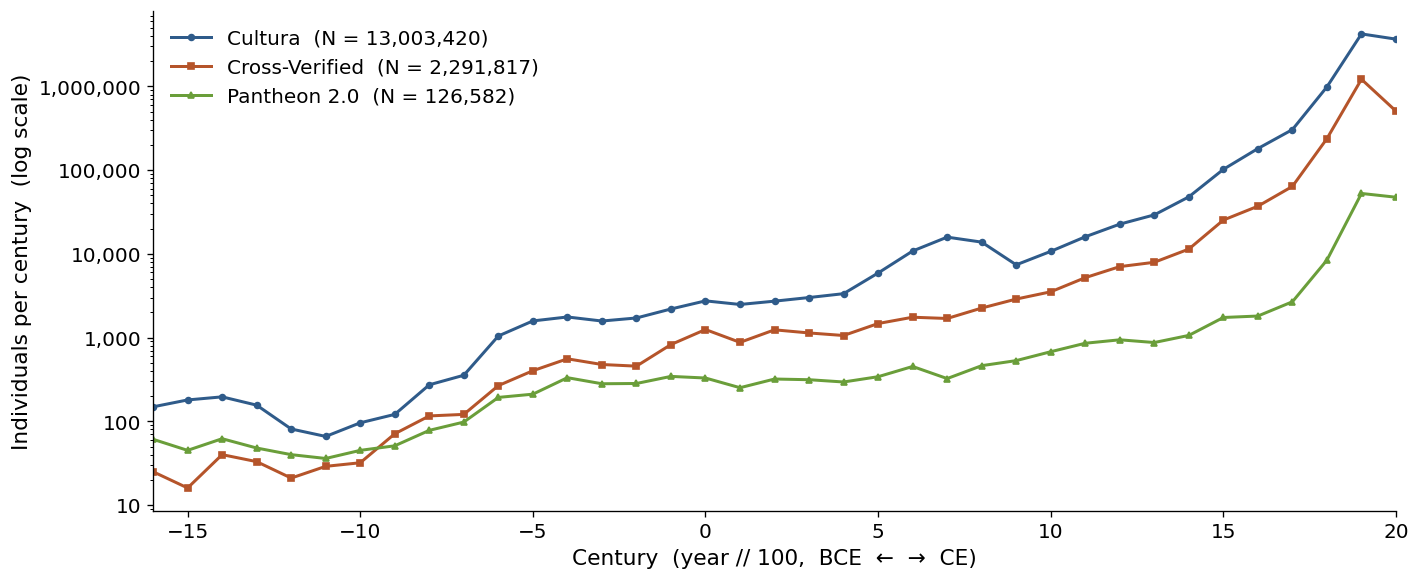

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
century_x = per_century['century'].to_list()
ax.plot(century_x, per_century['cultura'].to_list(),
        color=COLORS['cultura'], lw=1.8, marker='o', ms=3.5,
        label=f"Cultura  (N = {cultura_individuals.height:,})")
ax.plot(century_x, per_century['cross_verified'].to_list(),
        color=COLORS['cross_verified'], lw=1.8, marker='s', ms=3.5,
        label=f"Cross-Verified  (N = {cross_verified.height:,})")
ax.plot(century_x, per_century['pantheon_2'].to_list(),
        color=COLORS['pantheon_2'], lw=1.8, marker='^', ms=3.5,
        label=f"Pantheon 2.0  (N = {pantheon_2.height:,})")

ax.set_yscale('log')
ax.set_xlabel('Century  (year // 100,  BCE  ←  →  CE)', fontsize=13)
ax.set_ylabel('Individuals per century  (log scale)', fontsize=13)
ax.set_xlim(CENTURY_MIN, CENTURY_MAX)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{int(y):,}'))
ax.legend(loc='upper left', frameon=False, fontsize=12)
ax.tick_params(labelsize=12)
fig.tight_layout()
plt.show()

### Fig 2 — Normalized share per century  (each series sums to 100%)

In [11]:
per_century_share = per_century.with_columns(
    (pl.col('cultura')        / pl.col('cultura').sum()        * 100).alias('cultura_share_pct'),
    (pl.col('cross_verified') / pl.col('cross_verified').sum() * 100).alias('cross_verified_share_pct'),
    (pl.col('pantheon_2')     / pl.col('pantheon_2').sum()     * 100).alias('pantheon_2_share_pct'),
)

print('shape:', per_century_share.shape)
per_century_share.select('century', 'cultura_share_pct', 'cross_verified_share_pct', 'pantheon_2_share_pct').head()

shape: (37, 7)


century,cultura_share_pct,cross_verified_share_pct,pantheon_2_share_pct
i64,f64,f64,f64
-16,0.001539,0.001167,0.048805
-15,0.001859,0.000747,0.036003
-14,0.002024,0.001868,0.049605
-13,0.001611,0.001541,0.038404
-12,0.000837,0.000981,0.032003


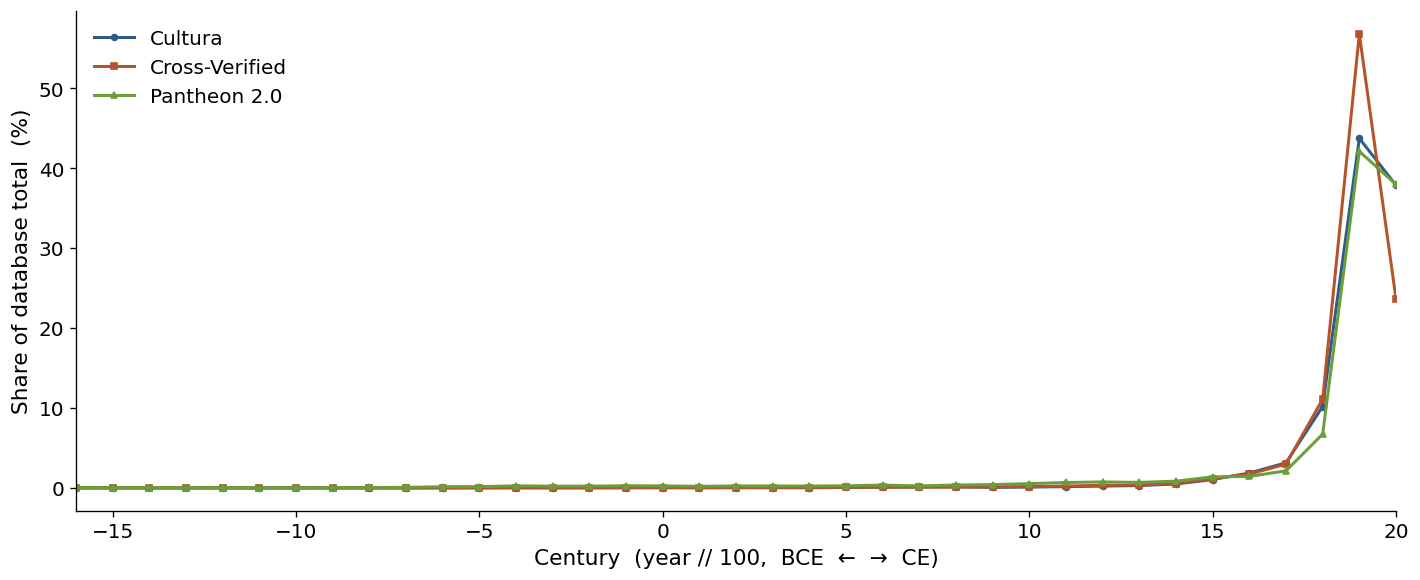

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(century_x, per_century_share['cultura_share_pct'].to_list(),
        color=COLORS['cultura'], lw=1.8, marker='o', ms=3.5, label='Cultura')
ax.plot(century_x, per_century_share['cross_verified_share_pct'].to_list(),
        color=COLORS['cross_verified'], lw=1.8, marker='s', ms=3.5, label='Cross-Verified')
ax.plot(century_x, per_century_share['pantheon_2_share_pct'].to_list(),
        color=COLORS['pantheon_2'], lw=1.8, marker='^', ms=3.5, label='Pantheon 2.0')

ax.set_xlabel('Century  (year // 100,  BCE  ←  →  CE)', fontsize=13)
ax.set_ylabel('Share of database total  (%)', fontsize=13)
ax.set_xlim(CENTURY_MIN, CENTURY_MAX)
ax.legend(loc='upper left', frameon=False, fontsize=12)
ax.tick_params(labelsize=12)
fig.tight_layout()
plt.show()

## Cross-Verified individuals missing from Cultura  (CV-side metadata)

In [13]:
cv_only = cross_verified.filter(
    pl.col('wikidata_code').is_not_null()
    & ~pl.col('wikidata_code').is_in(list(cultura_qids))
)

print('shape:', cv_only.shape)
cv_only.select('wikidata_code', 'name', 'birth', 'death', 'level1_main_occ', 'un_region').head()

shape: (19723, 9)


wikidata_code,name,birth,death,level1_main_occ,un_region
str,str,i64,i64,str,str
"""Q100259""","""Mortimer_von_Maltzan""",1793,1843,"""Leadership""","""Europe"""
"""Q10086788""","""Alois_Isidor_Jeitteles""",1794,1858,"""Culture""","""Europe"""
"""Q10089932""","""Jiang_Xu""",null,null,"""Leadership""","""Asia"""
"""Q1022228""","""Būrān""",807,884,"""Leadership""",null
"""Q10260629""","""Cornelio_Olivencia""",1788,1869,"""Leadership""","""America"""


### Top 10 occupations in the Cross-Verified-only set

In [14]:
TOP_K_OCCUPATIONS = 10

cv_only_top_occupations = (
    cv_only.with_columns(pl.col('level1_main_occ').fill_null('(unknown)'))
    .group_by('level1_main_occ').len().rename({'len': 'individuals'})
    .sort('individuals', descending=True)
    .head(TOP_K_OCCUPATIONS)
)

print('shape:', cv_only_top_occupations.shape)
cv_only_top_occupations

shape: (6, 2)


level1_main_occ,individuals
str,u32
"""Leadership""",6207
"""Culture""",5598
"""Sports/Games""",4450
"""Discovery/Science""",2424
"""Other""",683
"""Missing""",361


## Random sample — 10 individuals Cross-Verified has but Cultura misses

In [15]:
SAMPLE_SIZE = 10

cv_only_sample = (
    cv_only
    .sample(n=min(SAMPLE_SIZE, cv_only.height), seed=SEED)
    .select('wikidata_code', 'name', 'birth', 'death', 'level1_main_occ', 'un_region')
    .sort('birth')
)

print('shape:', cv_only_sample.shape)
cv_only_sample

shape: (10, 6)


wikidata_code,name,birth,death,level1_main_occ,un_region
str,str,i64,i64,str,str
"""Q16734679""","""J._J._Power""",null,null,"""Leadership""","""Europe"""
"""Q4696023""","""Ahmed_Shiyam""",null,null,"""Leadership""","""Asia"""
"""Q7153361""","""Paul_Rusling""",null,null,"""Culture""","""Europe"""
"""Q23901595""","""Willem_Roos""",1882,1915,"""Leadership""","""Europe"""
"""Q43388479""","""Armais_Arutunoff""",1893,1978,"""Discovery/Science""",null
"""Q7965761""","""Walter_P._Kellenberg""",1901,1986,"""Leadership""","""America"""
"""Q52064115""","""Isabel_Bas_Amat""",1931,null,"""Culture""","""Europe"""
"""Q19759817""","""Irini_Lambraki""",1949,2018,"""Leadership""","""Europe"""
"""Q56651231""","""Sidda_Raghava_Rao""",1957,null,"""Leadership""","""Asia"""


## Random sample — 10 individuals Cultura has but Cross-Verified misses

In [16]:
cultura_only_sample = (
    cultura_individuals
    .filter(pl.col('in_cross_verified') == 0)
    .filter(pl.col('floruit_year').is_not_null())
    .sample(n=SAMPLE_SIZE, seed=SEED)
    .select('wikidata_id', 'name_en', 'floruit_year')
    .sort('floruit_year')
)

print('shape:', cultura_only_sample.shape)
cultura_only_sample

shape: (10, 3)


wikidata_id,name_en,floruit_year
str,str,i64
"""Q96091316""","""Fahra Reuben""",1858
"""Q131358302""","""Leopoldo Hernández Partida""",1938
"""Q112787315""","""Jimmy Allen""",1957
"""Q11513075""","""Isao Hoshino""",1969
"""Q65563319""","""Françoise Agrain""",1983
"""Q9159708""","""Arkadiusz Dera""",1985
"""Q78050451""","""Balasubramanian Palaniappan""",1999
"""Q56529468""","""Joachim Klode""",2015
"""Q96064936""","""Mohammadreza Taherizadeh""",2017


## Western vs non-Western source classification  (used for the unified comparison table below)

In [ ]:
from constants import (
    WESTERN_COUNTRIES,
    WESTERN_WIKIPEDIA_LANGUAGES,
    NON_WESTERN_WIKIPEDIA_LANGUAGES,
)

CROSS_VERIFIED_SEVEN_LANGUAGES = ['en', 'fr', 'de', 'es', 'it', 'pt', 'sv']

print(f'WESTERN_COUNTRIES                : {len(WESTERN_COUNTRIES)} countries')
print(f'WESTERN_WIKIPEDIA_LANGUAGES      : {len(WESTERN_WIKIPEDIA_LANGUAGES)} language codes')
print(f'NON_WESTERN_WIKIPEDIA_LANGUAGES  : {len(NON_WESTERN_WIKIPEDIA_LANGUAGES)} language codes')

### Cultura — Western / non-Western catalog flag per individual

In [18]:
catalog_categories = cultura_con.execute(
    'SELECT property_id, country_name FROM identifier_types'
).pl().with_columns(
    pl.when(pl.col('country_name').is_in(WESTERN_COUNTRIES)).then(pl.lit('western'))
    .when(pl.col('country_name') == 'internationality').then(pl.lit('international'))
    .when(pl.col('country_name').is_not_null()).then(pl.lit('non_western'))
    .otherwise(None)
    .alias('category')
)

identifier_links = cultura_con.execute(
    'SELECT wikidata_id, property_id FROM identifiers'
).pl()

catalog_flags = (
    identifier_links
    .join(catalog_categories.filter(pl.col('category').is_not_null()).select('property_id', 'category'),
          on='property_id', how='inner')
    .group_by('wikidata_id')
    .agg(
        (pl.col('category') == 'western').any().alias('has_western_catalog'),
        (pl.col('category') == 'non_western').any().alias('has_non_western_catalog'),
        (pl.col('category') == 'international').any().alias('has_international_catalog'),
    )
)

print('shape:', catalog_flags.shape)
catalog_flags.head()

shape: (5797690, 4)


wikidata_id,has_western_catalog,has_non_western_catalog,has_international_catalog
str,bool,bool,bool
"""Q95690372""",true,true,false
"""Q102253261""",true,false,false
"""Q52826515""",true,false,false
"""Q21148738""",true,false,false
"""Q122178993""",false,true,false


### Cultura — Western / non-Western Wikipedia flag per individual  (also: any of the seven main CV editions)

In [19]:
wikipedia_links_classified = cultura_con.execute(
    "SELECT wikidata_id, site FROM wikimedia_links WHERE site LIKE '%.wikipedia.org'"
).pl().with_columns(
    pl.col('site').str.split('.').list.get(0).alias('language')
).with_columns(
    pl.when(pl.col('language').is_in(WESTERN_WIKIPEDIA_LANGUAGES)).then(pl.lit('western'))
    .when(pl.col('language').is_in(NON_WESTERN_WIKIPEDIA_LANGUAGES)).then(pl.lit('non_western'))
    .otherwise(None)
    .alias('category'),
    pl.col('language').is_in(CROSS_VERIFIED_SEVEN_LANGUAGES).alias('in_cv_seven_editions'),
)

wikipedia_flags = (
    wikipedia_links_classified
    .group_by('wikidata_id')
    .agg(
        pl.col('language').count().gt(0).alias('has_any_wikipedia'),
        (pl.col('category') == 'western').any().alias('has_western_wikipedia'),
        (pl.col('category') == 'non_western').any().alias('has_non_western_wikipedia'),
        pl.col('in_cv_seven_editions').any().alias('has_cv_seven_edition'),
    )
)

print('shape:', wikipedia_flags.shape)
wikipedia_flags.head()

shape: (4744471, 5)


wikidata_id,has_any_wikipedia,has_western_wikipedia,has_non_western_wikipedia,has_cv_seven_edition
str,bool,bool,bool,bool
"""Q2975078""",true,true,false,true
"""Q17811658""",true,true,false,true
"""Q635234""",true,true,true,true
"""Q24059409""",true,false,true,false
"""Q110822621""",true,false,true,false


## Unified comparison table — Cultura vs Cross-Verified vs Pantheon 2.0 vs three paper-only references

### Cultura — counts per dimension

In [20]:
cultura_with_polity     = cultura_con.execute(
    'SELECT COUNT(DISTINCT wikidata_id) FROM individuals_cliopatria'
).fetchone()[0]
cultura_with_floruit    = cultura_con.execute(
    'SELECT COUNT(*) FROM individuals_floruit_period WHERE floruit_period_start IS NOT NULL'
).fetchone()[0]
cultura_with_occupation = cultura_con.execute(
    "SELECT COUNT(*) FROM individuals WHERE occupations_en IS NOT NULL AND occupations_en != ''"
).fetchone()[0]

cultura_in_cv_seven       = wikipedia_flags.filter(pl.col('has_cv_seven_edition')).height
cultura_outside_cv_seven  = wikipedia_flags.filter(
    pl.col('has_any_wikipedia') & ~pl.col('has_cv_seven_edition')
).height
cultura_nw_wikipedia_only = wikipedia_flags.filter(
    ~pl.col('has_western_wikipedia') & pl.col('has_non_western_wikipedia')
).height
cultura_nw_catalog_only   = catalog_flags.filter(
    ~pl.col('has_western_catalog') & pl.col('has_non_western_catalog')
).height

cultura_counts = pl.DataFrame({
    'metric': [
        'total',
        'with polity',
        'with floruit period',
        'with occupation',
        'in any of CV seven Wikipedia editions',
        'in Wikipedia outside CV seven editions',
        'only in non-Western Wikipedia',
        'only in non-Western catalogs',
    ],
    'individuals': [
        cultura_individuals.height,
        cultura_with_polity,
        cultura_with_floruit,
        cultura_with_occupation,
        cultura_in_cv_seven,
        cultura_outside_cv_seven,
        cultura_nw_wikipedia_only,
        cultura_nw_catalog_only,
    ],
})

print('shape:', cultura_counts.shape)
cultura_counts

shape: (8, 2)


metric,individuals
str,i64
"""total""",13003420
"""with polity""",5065026
"""with floruit period""",9683814
"""with occupation""",9032397
"""in any of CV seven Wikipedia e…",3161811
"""in Wikipedia outside CV seven …",1582660
"""only in non-Western Wikipedia""",938970
"""only in non-Western catalogs""",258236


### Cross-Verified — counts per dimension

In [21]:
cv_seven_editions_set = {f'{language}wiki' for language in CROSS_VERIFIED_SEVEN_LANGUAGES}
western_wiki_set      = set(WESTERN_WIKIPEDIA_LANGUAGES)
non_western_wiki_set  = set(NON_WESTERN_WIKIPEDIA_LANGUAGES)

def classify_cv_editions(editions_string):
    if not isinstance(editions_string, str) or not editions_string:
        return {'has_western_wiki': False, 'has_non_western_wiki': False, 'in_cv_seven_editions': False}
    has_western = has_non_western = in_cv_seven = False
    for token in editions_string.split('|'):
        if token in cv_seven_editions_set:
            in_cv_seven = True
        language = token[:-4] if token.endswith('wiki') else token
        if language in western_wiki_set:
            has_western = True
        elif language in non_western_wiki_set:
            has_non_western = True
    return {'has_western_wiki': has_western, 'has_non_western_wiki': has_non_western, 'in_cv_seven_editions': in_cv_seven}

cv_editions = cross_verified_con.execute(
    'SELECT list_wikipedia_editions FROM individuals'
).pl().with_columns(
    pl.col('list_wikipedia_editions').map_elements(
        classify_cv_editions,
        return_dtype=pl.Struct([
            pl.Field('has_western_wiki', pl.Boolean),
            pl.Field('has_non_western_wiki', pl.Boolean),
            pl.Field('in_cv_seven_editions', pl.Boolean),
        ]),
    ).alias('flags')
).unnest('flags')

cv_with_citizenship = cross_verified_con.execute(
    'SELECT COUNT(*) FROM individuals WHERE citizenship_1_b IS NOT NULL'
).fetchone()[0]
cv_with_dates = cross_verified_con.execute(
    'SELECT COUNT(*) FROM individuals WHERE birth IS NOT NULL OR death IS NOT NULL'
).fetchone()[0]
cv_with_occupation = cross_verified_con.execute(
    "SELECT COUNT(*) FROM individuals WHERE level1_main_occ IS NOT NULL AND level1_main_occ != 'Missing'"
).fetchone()[0]
cv_in_seven        = cv_editions.filter(pl.col('in_cv_seven_editions')).height
cv_outside_seven   = cv_editions.filter(
    pl.col('list_wikipedia_editions').is_not_null() & ~pl.col('in_cv_seven_editions')
).height
cv_nw_wiki_only    = cv_editions.filter(
    ~pl.col('has_western_wiki') & pl.col('has_non_western_wiki')
).height

cv_counts = pl.DataFrame({
    'metric': [
        'total', 'with polity / citizenship', 'with floruit / birth-or-death date',
        'with occupation', 'in any of CV seven Wikipedia editions',
        'in Wikipedia outside CV seven editions', 'only in non-Western Wikipedia',
    ],
    'individuals': [
        cross_verified.height, cv_with_citizenship, cv_with_dates,
        cv_with_occupation, cv_in_seven, cv_outside_seven, cv_nw_wiki_only,
    ],
})

print('shape:', cv_counts.shape)
cv_counts

shape: (7, 2)


metric,individuals
str,i64
"""total""",2291817
"""with polity / citizenship""",2238318
"""with floruit / birth-or-death …",2140640
"""with occupation""",2276400
"""in any of CV seven Wikipedia e…",2290997
"""in Wikipedia outside CV seven …",820
"""only in non-Western Wikipedia""",169


### Pantheon 2.0 — counts per dimension

In [22]:
pantheon_2_with_country    = pantheon_2_con.execute(
    'SELECT COUNT(*) FROM individuals WHERE bplace_country IS NOT NULL OR dplace_country IS NOT NULL'
).fetchone()[0]
pantheon_2_with_dates      = pantheon_2_con.execute(
    'SELECT COUNT(*) FROM individuals WHERE birthyear IS NOT NULL OR deathyear IS NOT NULL'
).fetchone()[0]
pantheon_2_with_occupation = pantheon_2_con.execute(
    'SELECT COUNT(*) FROM individuals WHERE occupation IS NOT NULL'
).fetchone()[0]

pantheon_2_counts = pl.DataFrame({
    'metric':      ['total', 'with polity / citizenship', 'with floruit / birth-or-death date', 'with occupation'],
    'individuals': [pantheon_2.height, pantheon_2_with_country, pantheon_2_with_dates, pantheon_2_with_occupation],
})

print('shape:', pantheon_2_counts.shape)
pantheon_2_counts

shape: (4, 2)


metric,individuals
str,i64
"""total""",126582
"""with polity / citizenship""",123104
"""with floruit / birth-or-death …",125324
"""with occupation""",126520


### HBR / Schich 2014 / Chaney 2024 — paper-derived constants  (Nekoei & Sinn 2020 Table 1; Schich et al. 2014; Chaney 2024)

In [23]:
HBR_TOTAL                = 7_015_353
HBR_WITH_COUNTRY         = round(HBR_TOTAL * 0.7759)
HBR_WITH_BIRTH           = round(HBR_TOTAL * 0.6043)
HBR_WITH_OCCUPATION      = round(HBR_TOTAL * 0.7590)

SCHICH_FB_TOTAL          = 120_211

CHANEY_TOTAL             = 537_247
CHANEY_WITH_REGION       = 486_179
CHANEY_WITH_DATES        = 537_247
CHANEY_WITH_OCCUPATION   = 537_247

### Build the unified comparison table

In [24]:
DASH = '—'

comparison_rows = [
    ('Total individuals',
        cultura_individuals.height,    cross_verified.height,        pantheon_2.height,           HBR_TOTAL,           SCHICH_FB_TOTAL, CHANEY_TOTAL),
    ('With polity / citizenship',
        cultura_with_polity,           cv_with_citizenship,          pantheon_2_with_country,     HBR_WITH_COUNTRY,    DASH,            CHANEY_WITH_REGION),
    ('With floruit / birth-or-death date',
        cultura_with_floruit,          cv_with_dates,                pantheon_2_with_dates,       HBR_WITH_BIRTH,      SCHICH_FB_TOTAL, CHANEY_WITH_DATES),
    ('With occupation',
        cultura_with_occupation,       cv_with_occupation,           pantheon_2_with_occupation,  HBR_WITH_OCCUPATION, DASH,            CHANEY_WITH_OCCUPATION),
    ('In any of the seven main CV Wikipedia editions',
        cultura_in_cv_seven,           cv_in_seven,                  DASH,                        DASH,                DASH,            DASH),
    ('In Wikipedia outside the seven main CV editions',
        cultura_outside_cv_seven,      cv_outside_seven,             DASH,                        DASH,                DASH,            DASH),
    ('Only in non-Western Wikipedia',
        cultura_nw_wikipedia_only,     cv_nw_wiki_only,              DASH,                        DASH,                DASH,            DASH),
    ('Only in non-Western catalogs',
        cultura_nw_catalog_only,       DASH,                         DASH,                        DASH,                DASH,            DASH),
]

def format_value(value):
    return f'{value:,}' if isinstance(value, (int, np.integer)) else value

comparison_table = pl.DataFrame({
    'dimension':       [r[0]               for r in comparison_rows],
    'cultura':         [format_value(r[1]) for r in comparison_rows],
    'cross_verified':  [format_value(r[2]) for r in comparison_rows],
    'pantheon_2':      [format_value(r[3]) for r in comparison_rows],
    'hbr':             [format_value(r[4]) for r in comparison_rows],
    'schich_2014':     [format_value(r[5]) for r in comparison_rows],
    'chaney_2024':     [format_value(r[6]) for r in comparison_rows],
})

print('shape:', comparison_table.shape)
with pl.Config(tbl_cols=-1, tbl_width_chars=200, fmt_str_lengths=80):
    print(comparison_table)

shape: (8, 7)
shape: (8, 7)
┌─────────────────────────────────────────────────┬────────────┬────────────────┬────────────┬───────────┬─────────────┬─────────────┐
│ dimension                                       ┆ cultura    ┆ cross_verified ┆ pantheon_2 ┆ hbr       ┆ schich_2014 ┆ chaney_2024 │
│ ---                                             ┆ ---        ┆ ---            ┆ ---        ┆ ---       ┆ ---         ┆ ---         │
│ str                                             ┆ str        ┆ str            ┆ str        ┆ str       ┆ str         ┆ str         │
╞═════════════════════════════════════════════════╪════════════╪════════════════╪════════════╪═══════════╪═════════════╪═════════════╡
│ Total individuals                               ┆ 13,003,420 ┆ 2,291,817      ┆ 126,582    ┆ 7,015,353 ┆ 120,211     ┆ 537,247     │
│ With polity / citizenship                       ┆ 5,065,026  ┆ 2,238,318      ┆ 123,104    ┆ 5,443,212 ┆ —           ┆ 486,179     │
│ With floruit / birth-or-d

In [27]:
cultura_con.close()
cross_verified_con.close()
pantheon_2_con.close()